In [2]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit

In [2]:
import os
os.getcwd()

'/export/scratch/users/rodr1001/my_code/my_code/ldmx/hgcroc/pedestal_data/data'

In [3]:
# Gaussian function
def Gauss(x, A, B):
    return A * np.exp(-B * x**2)

In [3]:
pedestal = pd.read_csv('default_pedestal_10k.csv')

In [4]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [5]:
#pedestal.head() - looking at updated csv

In [4]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

In [49]:
hist.Hist.new.StrCategory

<bound method QuickConstruct.StrCat of QuickConstruct(Hist, )>

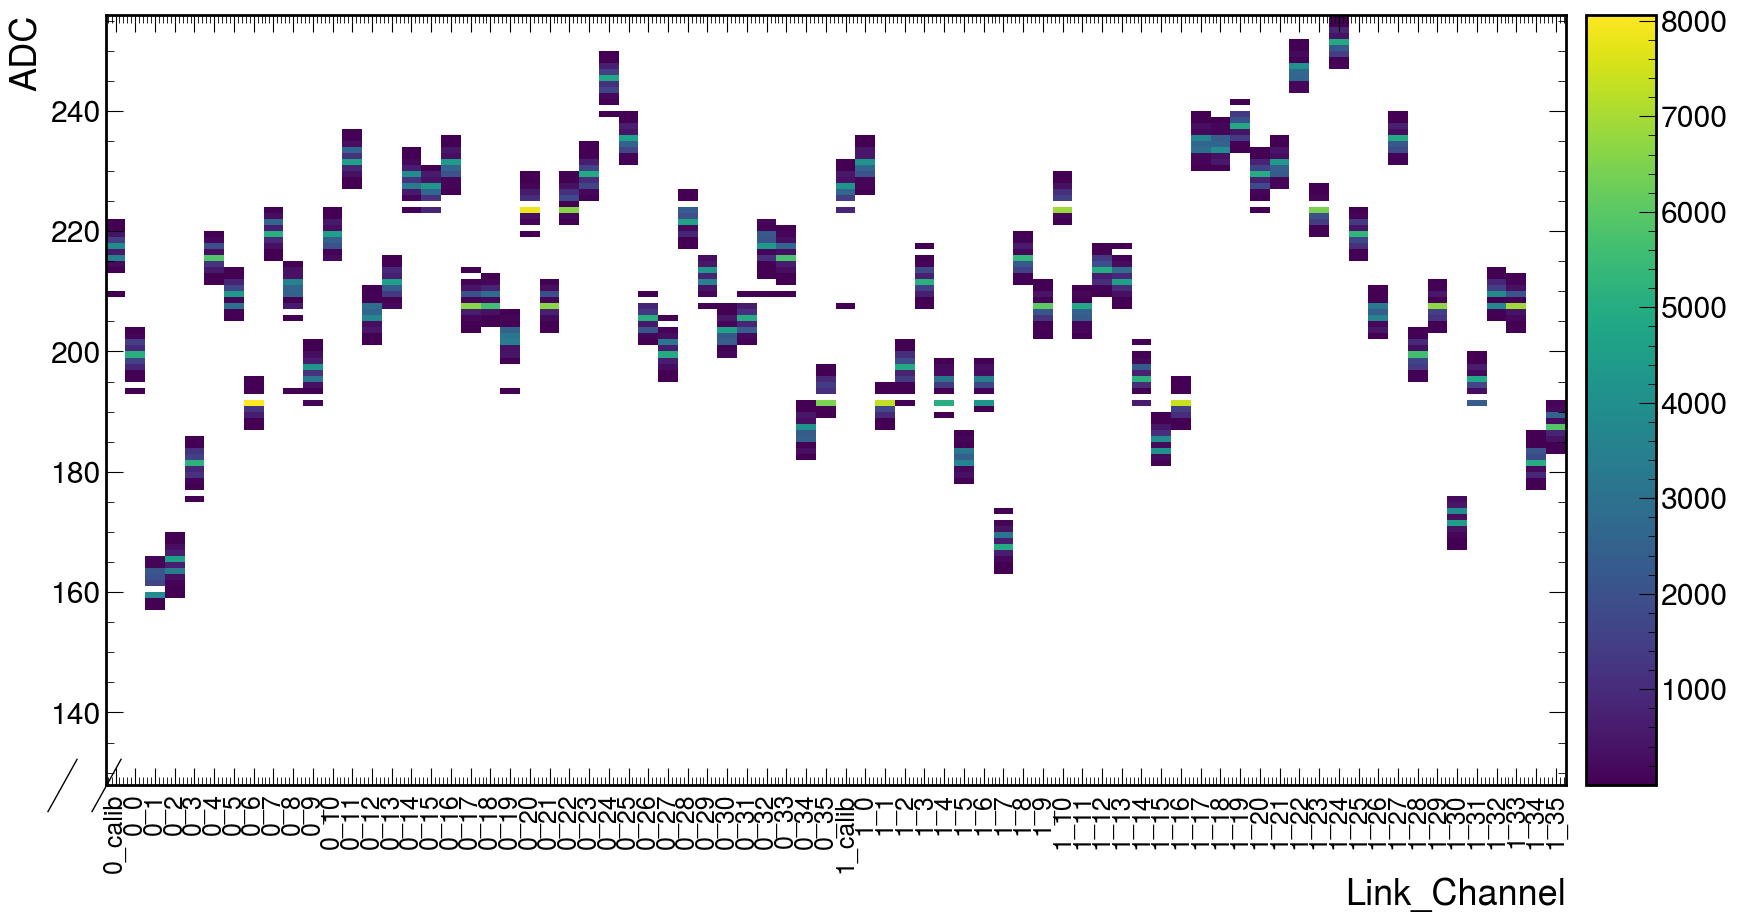

In [9]:
#general ADC Plot
fill_and_plot_all_channels('adc','ADC',128,256)

In [5]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning silides
link_1 = pedestal[pedestal['i_link'] ==1]


In [20]:
link_1.tail()
#link_0.describe() - looking at the new arrays generated

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa,uid
739995,1,14,31,0,31,False,False,195,195,-1,0,1_31
739996,1,14,31,0,32,False,False,209,213,-1,0,1_32
739997,1,14,31,0,33,False,False,209,207,-1,0,1_33
739998,1,14,31,0,34,False,False,183,183,-1,0,1_34
739999,1,14,31,0,35,False,False,189,187,-1,0,1_35


For Link 0, Min ADC is 157, Max is 249, Min ADC T-1 is 130, max is 249
For Link 1, Min ADC is 163, Max is 255, Min ADC T-1 is 130, Max is 255

In [6]:
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0')

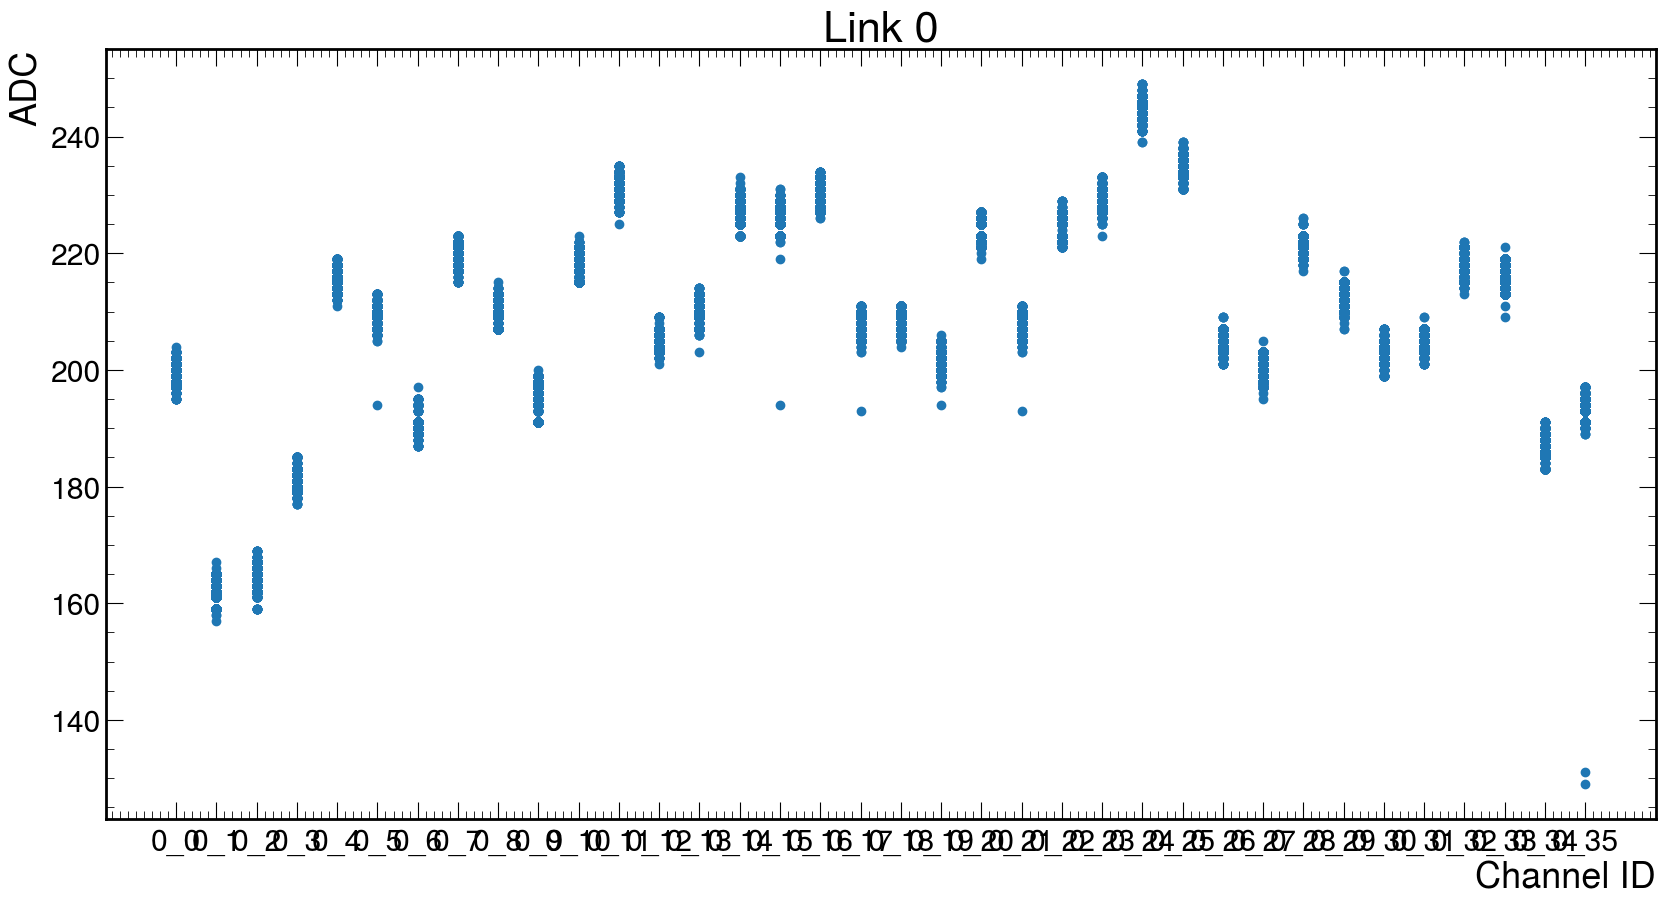

In [7]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [8]:
print ("Link 0 median ADC is " + str(link_0_norm['adc'].median()) + " without calibration channels")
print ("Link 0 mean ADC is " + str(link_0_norm['adc'].mean()) + " without calibration channels")



Link 0 median ADC is 209.0 without calibration channels
Link 0 mean ADC is 209.33851944444444 without calibration channels


Text(0.5, 1.0, 'Link 0')

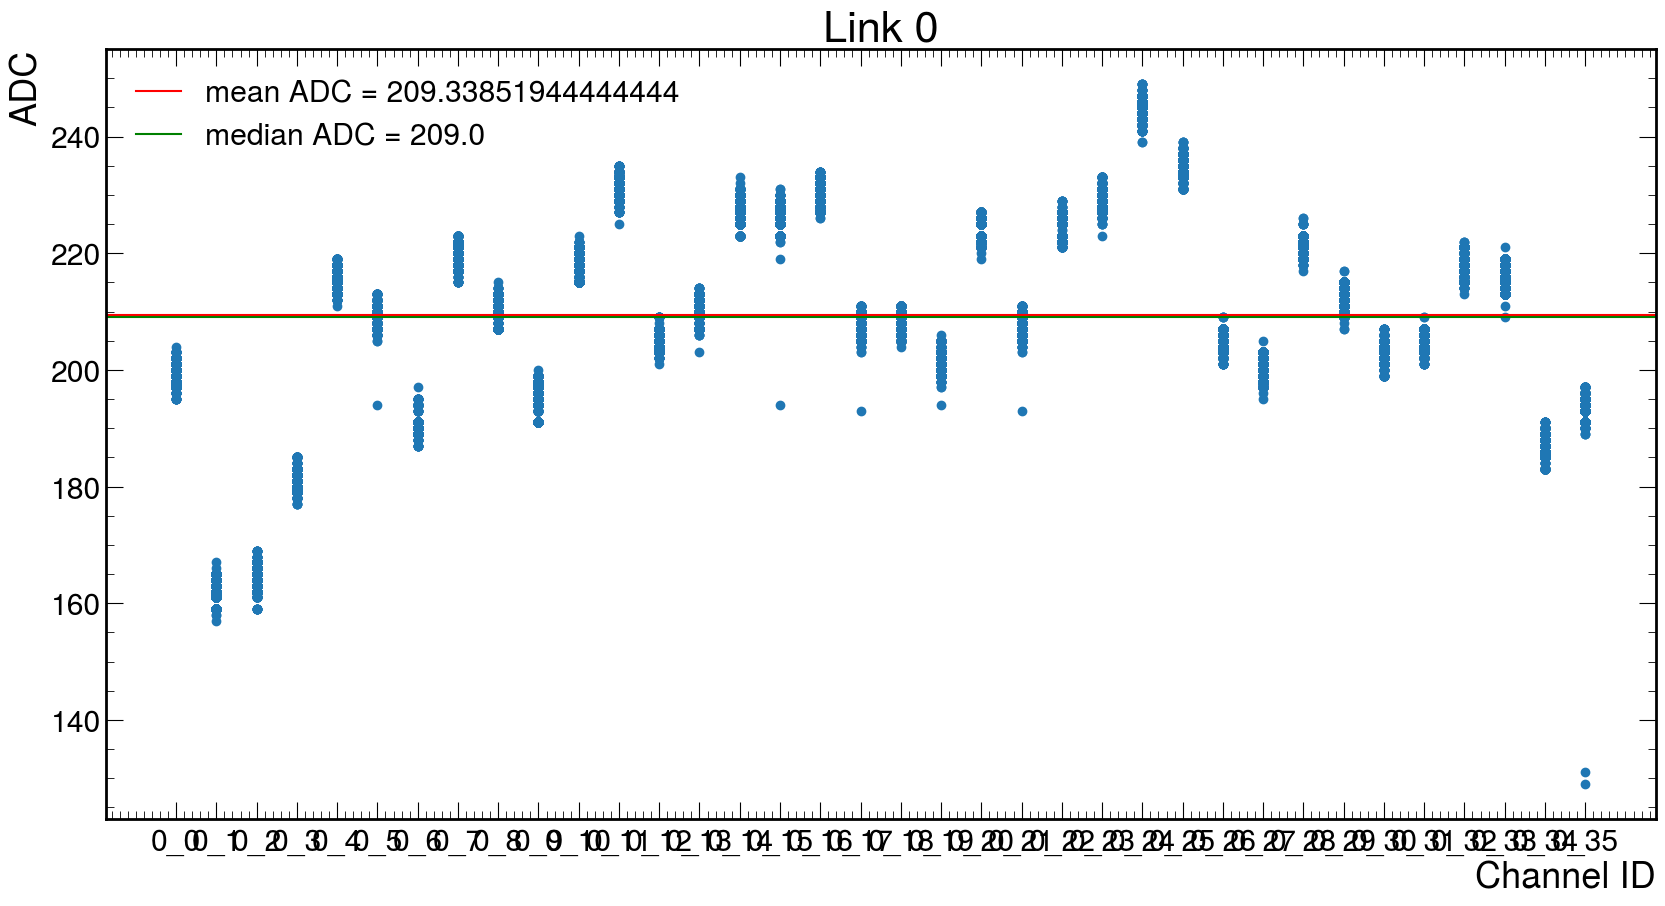

In [9]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.axhline(y=(link_0_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_0_norm['adc'].mean()) )
plt.axhline(y = (link_0_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_0_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [10]:
print ("Link 1 median ADC is " + str(link_1_norm['adc'].median()) + " without calibration channels")
print ("Link 1 mean ADC is " + str(link_1_norm['adc'].mean()) + " without calibration channels")


Link 1 median ADC is 207.0 without calibration channels
Link 1 mean ADC is 209.0195361111111 without calibration channels


Text(0.5, 1.0, 'Link 1')

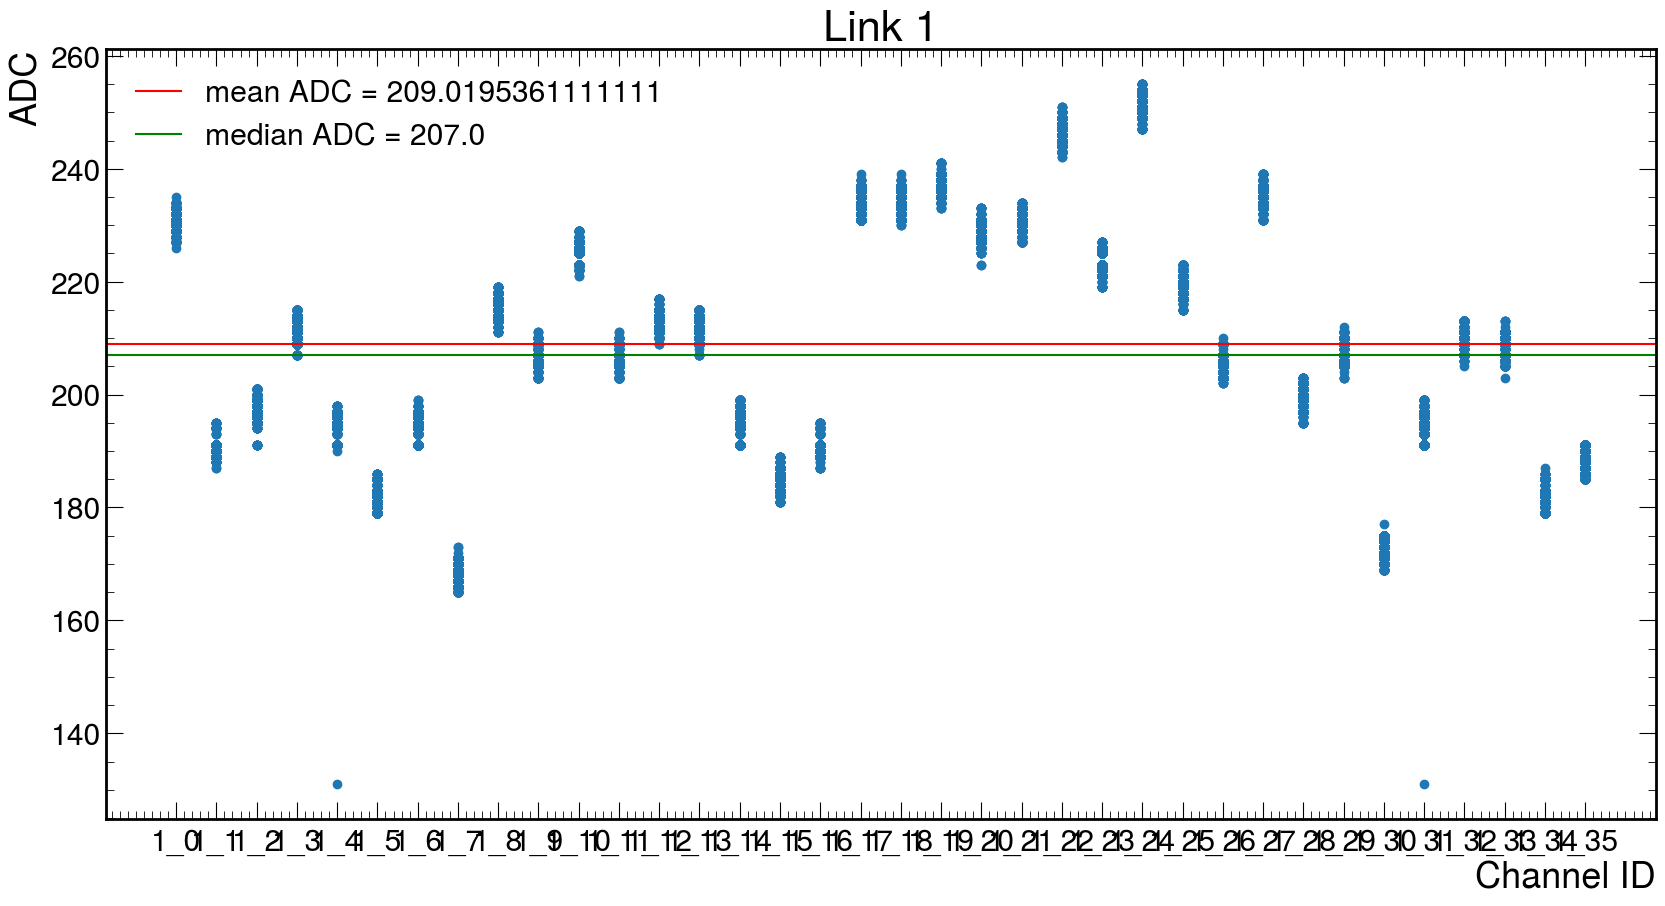

In [11]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
plt.axhline(y=(link_1_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_1_norm['adc'].mean()) )
plt.axhline(y = (link_1_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_1_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1")

Text(0.5, 1.0, 'Link 0 channel median')

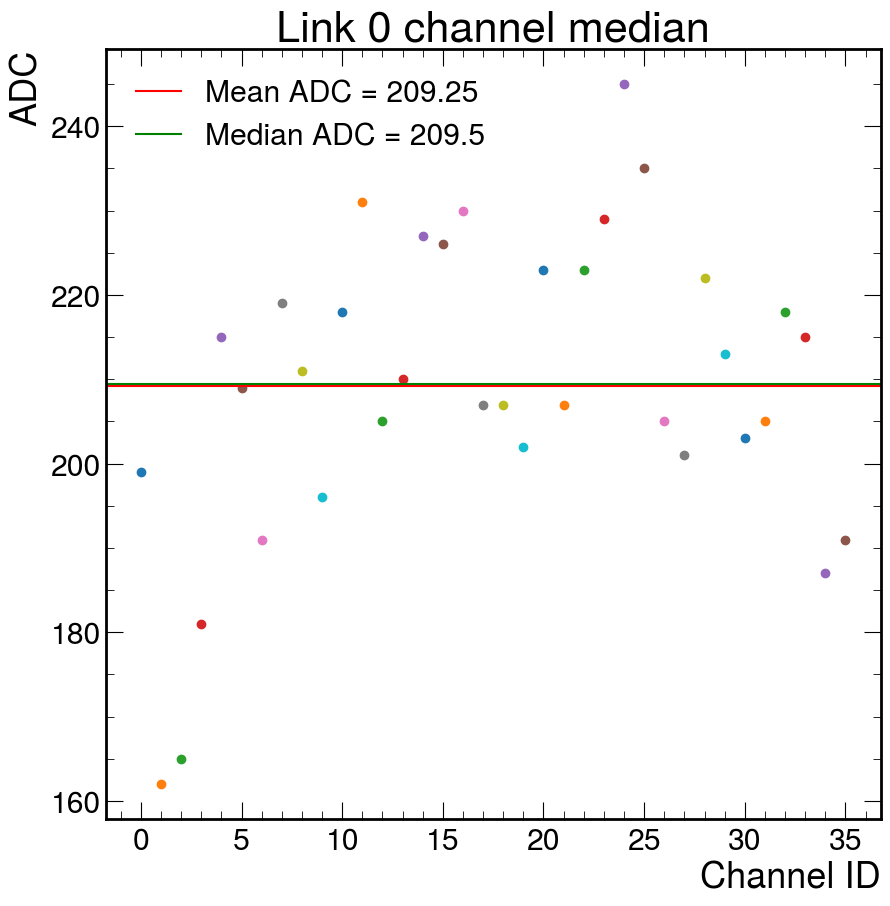

In [121]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
l0_ch_stddev = []
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
    l0_ch_stddev.append(ch_stddev)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
link_0_mean = np.mean(l0_ch_med)
plt.axhline(y=link_0_mean, color='r', label ="Mean ADC = " + str(link_0_mean))
plt.axhline(y=link_0_median, color='g', label = "Median ADC = " + str(link_0_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 1 channel median')

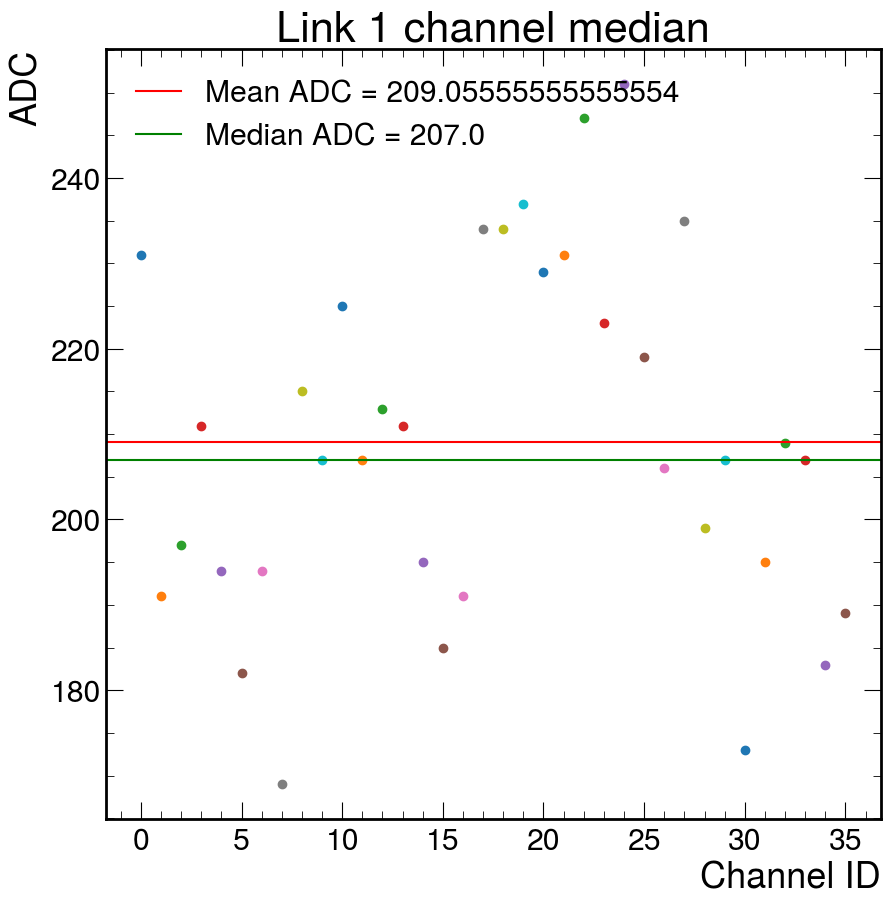

In [120]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
link_1_mean = np.mean(l1_ch_med)
plt.axhline(y=link_1_mean, color='r', label ="Mean ADC = " + str(link_1_mean))
plt.axhline(y=link_1_median, color='g', label = "Median ADC = " + str(link_1_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [ ]:
# {"parameter_points_file":"ch24_setting_dacb.csv","channel":24,"nevents_per_point":5,"trigger":"PEDESTAL","scan_wide_params":{"HALFWISE_0":{"SIGN_DAC":1}}}
 

In [16]:
high_triminv_ped = pd.read_csv('high_triminv_pedestal_10k.csv')
high_triminv_ped['uid'] = high_triminv_ped['i_link'].astype(str)+'_'+high_triminv_ped['channel']



In [24]:
high_triminv_ped_norm = high_triminv_ped[high_triminv_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians


In [26]:
highlink_0 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning silides
highlink_1 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==1 ]



In [122]:
highlink_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_0[highlink_0['channel'] == str(i)]['adc'].median()
    highlink_0_med.append(median)

In [123]:
highlink_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_1[highlink_1['channel'] == str(i)]['adc'].median()
    highlink_1_med.append(median)

In [30]:
 ## i want to find the value of the parameter trim_inv when ADC is at the median, my y value is the value of the parameter, triminv, for high_trim_inv, it's 63, for low/default it's 0

In [124]:
len(highlink_1_med)

36

In [65]:
link_1_channel_num =[]
for i in range (36, 72):
    link_1_channel_num.append(i)

In [60]:
highlink_1_med[15]

229.0

In [61]:
l1_ch_med[15]

185.0

In [62]:
### so for channel 0, 
adc_values = [l1_ch_med[15],highlink_1_med[15]]
trim_inv = [0,63]
link_1_median ## evaluate at this value

207.0

In [68]:
link_1_channel_num[15]

51

In [90]:
##imadine ADC is on the x axis, im looking for the corresponding y
round(np.interp(link_1_median, adc_values, trim_inv))

32

In [ ]:
trim_inv = [0,63]
link_1_channel_num =[]
for i in range (36, 72):
    link_1_channel_num.append(i)

In [143]:
dacb = [0,31]
sign_dac = 1
with open ('neg_dacb_test.txt', 'w') as  f:
    f.write('ROC')
    f.write('\n')
    for i in dacb_channels:
        f.write('POKE')
        f.write('\n')
        f.write(i)
        f.write('\n')
        f.write('SIGN_DAC')
        f.write('\n')
        f.write('1')
        f.write('\n')
    f.write ('DUMP')
    f.write('\n')
    f.write('neg_dacb_testsettings.yaml')
    f.write('\n')
    f.write('EXIT')
    f.write('\n')
    f.write('EXIT')


In [144]:
dacb = [0,31]
sign_dac = 1
with open ('neg_high_dacb_test.txt', 'w') as  f:
    f.write('ROC')
    f.write('\n')
    for i in dacb_channels:
        f.write('POKE')
        f.write('\n')
        f.write(i)
        f.write('\n')
        f.write('DACB')
        f.write('\n')
        f.write('31')
        f.write('\n')
    f.write ('DUMP')
    f.write('\n')
    f.write('neg_high_dacb_testsettings.yaml')
    f.write('\n')
    f.write('EXIT')
    f.write('\n')
    f.write('EXIT')


In [146]:
neg_high_dacb_ped = pd.read_csv('neg_high_dacb_pedestal_10k.csv')
neg_high_dacb_ped['uid'] = neg_high_dacb_ped['i_link'].astype(str)+'_'+neg_high_dacb_ped['channel']
neg_high_dacb_ped = neg_high_dacb_ped[neg_high_dacb_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians
dacb_link_0 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning silides
dacb_link_1 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==1 ]






In [149]:
dacb_channels

['CH_4',
 'CH_7',
 'CH_8',
 'CH_10',
 'CH_11',
 'CH_13',
 'CH_14',
 'CH_15',
 'CH_16',
 'CH_20',
 'CH_22',
 'CH_23',
 'CH_24',
 'CH_25',
 'CH_28',
 'CH_29',
 'CH_32',
 'CH_33',
 'CH_36',
 'CH_39',
 'CH_44',
 'CH_45',
 'CH_46',
 'CH_47',
 'CH_48',
 'CH_49',
 'CH_53',
 'CH_54',
 'CH_55',
 'CH_56',
 'CH_57',
 'CH_58',
 'CH_59',
 'CH_60',
 'CH_61',
 'CH_63',
 'CH_65',
 'CH_68',
 'CH_69']

Text(0.5, 1.0, 'Link 0 (neg high dacb test)')

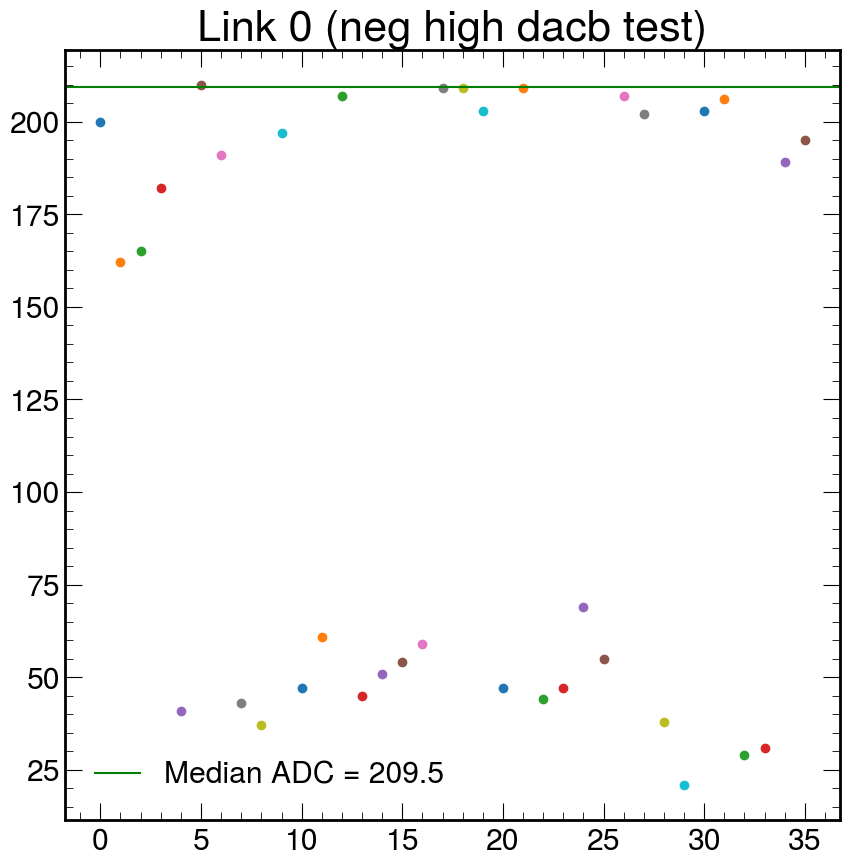

In [161]:
dacb_link_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_0[dacb_link_0['channel'] == str(i)]['adc'].median()
    dacb_link_0_med.append(median)
    plt.scatter(i, median)
plt.axhline(y=link_0_median, color='g', label = "Median ADC = " + str(link_0_median))
plt.legend(loc="best")
plt.title("Link 0 (neg high dacb test)")

Text(0.5, 1.0, 'Link 1 (neg high dacb test)')

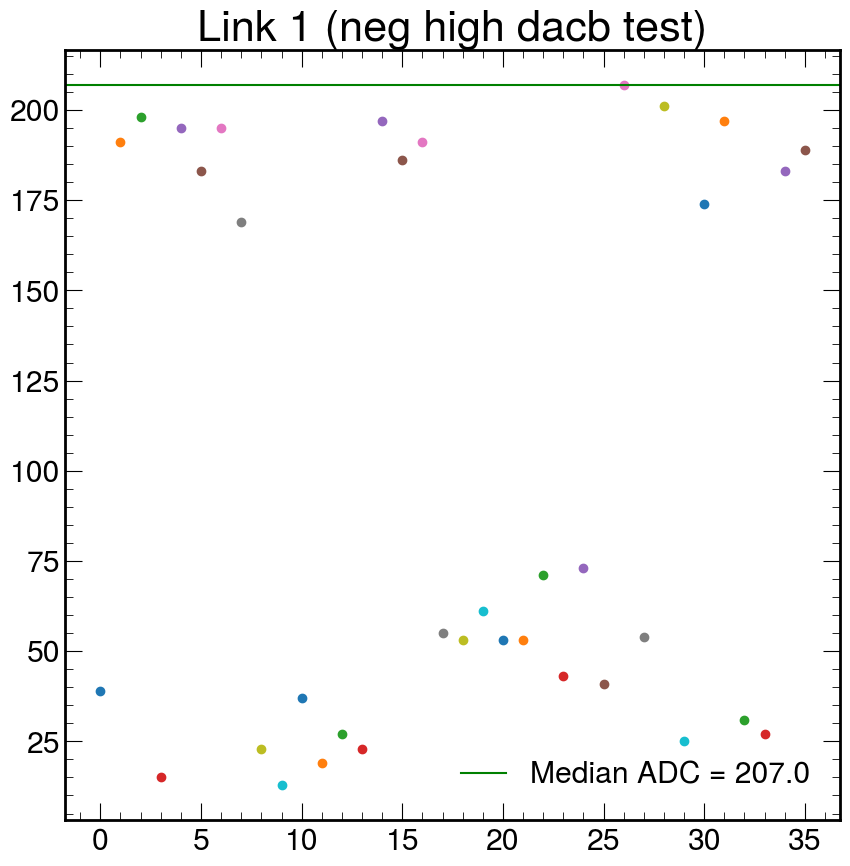

In [162]:
dacb_link_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_1[dacb_link_1['channel'] == str(i)]['adc'].median()
    dacb_link_1_med.append(median)
    plt.scatter(i,median)
plt.axhline(y=link_1_median, color='g', label = "Median ADC = " + str(link_1_median))
plt.legend(loc="best")
plt.title("Link 1 (neg high dacb test)")
    

In [163]:
adc_values = [dacb_link_1_med[7],l0_ch_med[7]]
dacb = [0,31]
link_0_median ## evaluate at this value


209.5

In [164]:
round(np.interp(link_0_median, adc_values, dacb))

25

In [169]:
default_triminv= 0
for a in range(15):
    name = "CH_" + str(a)
    if l0_ch_med[a] >= link_0_median :
        sign_dac = 1
        adc_values = [dacb_link_0_med[a],l0_ch_med[a]]
        new_dacb = round(np.interp(link_0_median, adc_values, dacb))
        channels[name] ={"TRIM_INV" : default_triminv,"DACB" : new_dacb, "SIGN_DAC": sign_dac}
        #print (name + " has a new dacb " + str(new_dacb))

In [170]:
channels

{'CH_0': {'TRIM_INV': 14},
 'CH_1': {'TRIM_INV': 61},
 'CH_2': {'TRIM_INV': 58},
 'CH_3': {'TRIM_INV': 37},
 'CH_4': {'TRIM_INV': 0, 'DACB': 30, 'SIGN_DAC': 1},
 'CH_5': {'TRIM_INV': 1},
 'CH_6': {'TRIM_INV': 24},
 'CH_7': {'TRIM_INV': 0, 'DACB': 29, 'SIGN_DAC': 1},
 'CH_8': {'TRIM_INV': 0, 'DACB': 31, 'SIGN_DAC': 1},
 'CH_9': {'TRIM_INV': 18},
 'CH_10': {'TRIM_INV': 0, 'DACB': 29, 'SIGN_DAC': 1},
 'CH_11': {'TRIM_INV': 0, 'DACB': 27, 'SIGN_DAC': 1},
 'CH_12': {'TRIM_INV': 6},
 'CH_13': {'TRIM_INV': 0, 'DACB': 31, 'SIGN_DAC': 1},
 'CH_14': {'TRIM_INV': 0, 'DACB': 28, 'SIGN_DAC': 1},
 'CH_15': {'TRIM_INV': 0},
 'CH_16': {'TRIM_INV': 0},
 'CH_17': {'TRIM_INV': 3},
 'CH_18': {'TRIM_INV': 3},
 'CH_19': {'TRIM_INV': 10},
 'CH_20': {'TRIM_INV': 0},
 'CH_21': {'TRIM_INV': 3},
 'CH_22': {'TRIM_INV': 0},
 'CH_23': {'TRIM_INV': 0},
 'CH_24': {'TRIM_INV': 0},
 'CH_25': {'TRIM_INV': 0},
 'CH_26': {'TRIM_INV': 6},
 'CH_27': {'TRIM_INV': 11},
 'CH_28': {'TRIM_INV': 0},
 'CH_29': {'TRIM_INV': 0},
 'C

In [140]:
channels = {}
default_triminv= 0
trim_inv = [0,63]
dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < link_0_median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(link_0_median, adc_values, trim_inv))
        channels[name] ={"TRIM_INV" : new_triminv}
    else:
        channels[name] ={"TRIM_INV" : default_triminv, }
        dacb_channels.append(name)
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < link_1_median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(link_1_median, adc_values, trim_inv))
        channels[name] ={"TRIM_INV" : new_triminv}
    else:
        channels[name] ={"TRIM_INV" : default_triminv}
        dacb_channels.append(name)
            

In [171]:
channels = {}
default_triminv= 0
default_dacb = 0
default_sign_dac = 0
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [0,31]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < link_0_median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(link_0_median, adc_values, trim_inv))
        channels[name] ={"TRIM_INV" : new_triminv,"DACB" : default_dacb, "SIGN_DAC": default_sign_dac}
    else:
        adc_values = [dacb_link_0_med[a],l0_ch_med[a]]
        new_dacb = round(np.interp(link_0_median, adc_values, dacb))
        channels[name] ={"TRIM_INV" : default_triminv,"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < link_1_median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(link_1_median, adc_values, trim_inv))
        channels[name] ={"TRIM_INV" : new_triminv,"DACB" : default_dacb, "SIGN_DAC": default_sign_dac}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(link_1_median, adc_values, dacb))
        channels[name] ={"TRIM_INV" : default_triminv,"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
            

In [172]:
channels

{'CH_0': {'TRIM_INV': 14, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_1': {'TRIM_INV': 61, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_2': {'TRIM_INV': 58, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_3': {'TRIM_INV': 37, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_4': {'TRIM_INV': 0, 'DACB': 30, 'SIGN_DAC': 1},
 'CH_5': {'TRIM_INV': 1, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_6': {'TRIM_INV': 24, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_7': {'TRIM_INV': 0, 'DACB': 29, 'SIGN_DAC': 1},
 'CH_8': {'TRIM_INV': 0, 'DACB': 31, 'SIGN_DAC': 1},
 'CH_9': {'TRIM_INV': 18, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_10': {'TRIM_INV': 0, 'DACB': 29, 'SIGN_DAC': 1},
 'CH_11': {'TRIM_INV': 0, 'DACB': 27, 'SIGN_DAC': 1},
 'CH_12': {'TRIM_INV': 6, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_13': {'TRIM_INV': 0, 'DACB': 31, 'SIGN_DAC': 1},
 'CH_14': {'TRIM_INV': 0, 'DACB': 28, 'SIGN_DAC': 1},
 'CH_15': {'TRIM_INV': 0, 'DACB': 28, 'SIGN_DAC': 1},
 'CH_16': {'TRIM_INV': 0, 'DACB': 27, 'SIGN_DAC': 1},
 'CH_17': {'TRIM_INV': 3, 'DACB': 0, 'SIGN_DAC': 0},
 'CH_18': {'TRIM_INV': 3, 'DACB': 0, 'SIG

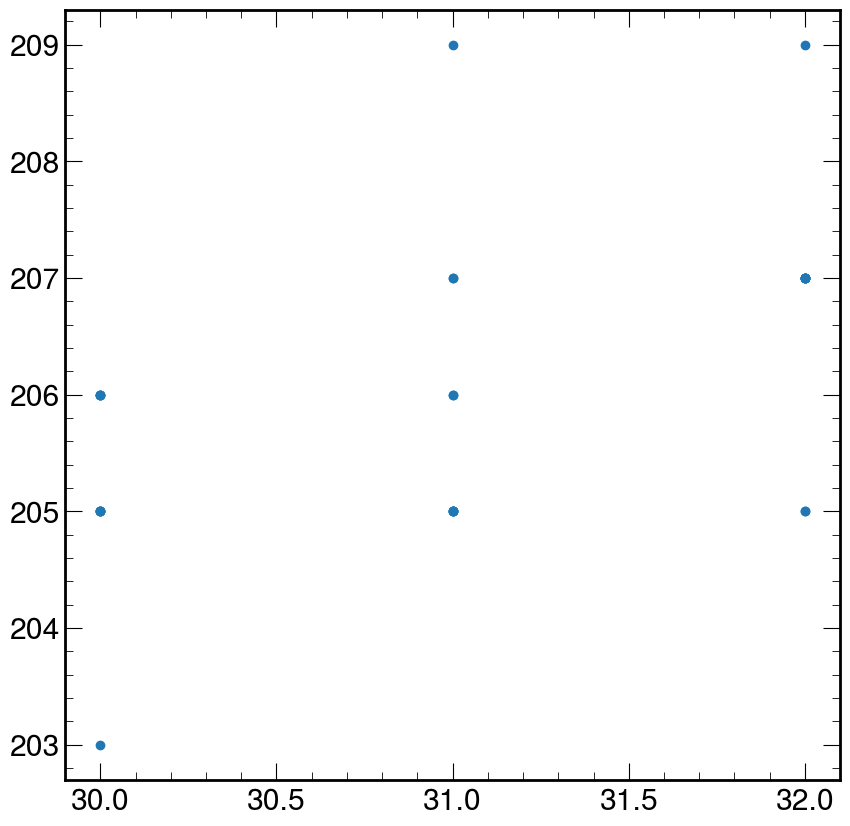

In [86]:
plt.scatter(ch51.TRIM_INV,ch51.adc)